### MobileNetV2 PTQ writer showcase

This notebook builds a **minimal MobileNetV2 binary classifier** on **CIFAR-10** and then applies **post-training quantization (PTQ)**. It is designed to showcase the **CEMI writer API** end to end, including:

- run lifecycle (`start_run`, `update_status`, `end_run`, `emit_run_record`)
- notebook metadata namespaces (`writer.case.set`, `writer.policy.set`, `writer.device.set`)
- tags, notes, lineage, and parameters
- event metrics, summary metrics, typed summaries, and table scalars
- benchmark helpers (`log_benchmark_config`, `log_mlperf_summary`, `log_latency_sample`, `log_operator_hotspot`)
- local and external artifacts

The task is intentionally small so the workflow is practical in a notebook: **airplane vs automobile** from CIFAR-10, trained for a few epochs, then quantized and logged as a second run.

### Writer APIs exercised here

This demo intentionally uses the following writer calls:

- `create_writer`
- `start_run`, `update_status`, `set_times`, `end_run`, `emit_run_record`
- `set_notes`, `set_tags`, `add_tag`, `set_lineage`
- `writer.case.set`, `writer.policy.set`, `writer.device.set`
- `set_case`, `set_policy`, `set_device` aliases are compatible, but this notebook uses the namespaced form
- `log_parameter`, `log_metric`, `log_summary`, `log_summary_metrics`, `log_scalar`, `log_scalars`
- `log_benchmark_config`, `log_mlperf_summary`, `log_latency_sample`, `log_operator_hotspot`
- `add_local_file_artifact`, `add_artifact`

If you run this notebook and then open CEMI compare, you should see structured `Case`, `Target Device`, and `Decision Policy` metadata flow through from the writer.

In [1]:
import copy
import io
import json
import math
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, f1_score
from torch.ao.quantization import get_default_qconfig_mapping
from torch.ao.quantization.quantize_fx import convert_fx, prepare_fx
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

%matplotlib inline

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "cli").exists():
    REPO_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "cli").exists():
    REPO_ROOT = CURRENT_DIR.parent
else:
    REPO_ROOT = CURRENT_DIR

if str(REPO_ROOT / "cli") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "cli"))

from cemi.writer import create_writer

In [2]:
SEED = 7
PROJECT_NAME = "mobilenet-cifar10-writer-showcase"
DEMO_DIR = REPO_ROOT / "demos"
NOTEBOOK_PATH = DEMO_DIR / "MobileNet_CIFAR10_Writer_Showcase.ipynb"
LOG_DIR = REPO_ROOT / ".cemi"
ARTIFACT_DIR = DEMO_DIR / "generated_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {0: "airplane", 1: "automobile"}
SELECTED_CLASSES = tuple(CLASS_NAMES.keys())
IMAGE_SIZE = 224
TRAIN_PER_CLASS = 500
VAL_PER_CLASS = 120
BATCH_SIZE = 32
EPOCHS = 2
LEARNING_RATE = 1e-3
CALIBRATION_BATCHES = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)


def now_iso() -> str:
    return datetime.now(timezone.utc).isoformat().replace("+00:00", "Z")


print(f"Using device: {DEVICE}")
print(f"Resolved repo root: {REPO_ROOT}")
print(f"Logs will be written to: {LOG_DIR}")

Using device: cpu
Resolved repo root: /media/volume/volume-dev/projects/cemi
Logs will be written to: /media/volume/volume-dev/projects/cemi/.cemi


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class BinaryCIFAR10(Dataset):
    def __init__(self, root: str, train: bool, transform, classes: tuple[int, int], max_per_class: int) -> None:
        self.dataset = datasets.CIFAR10(root=root, train=train, download=True, transform=transform)
        counts = {cls: 0 for cls in classes}
        self.indices = []
        self.label_map = {classes[0]: 0, classes[1]: 1}
        for idx, target in enumerate(self.dataset.targets):
            if target not in self.label_map:
                continue
            if counts[target] >= max_per_class:
                continue
            self.indices.append(idx)
            counts[target] += 1
            if all(count >= max_per_class for count in counts.values()):
                break

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        image, target = self.dataset[self.indices[idx]]
        return image, torch.tensor(self.label_map[int(target)], dtype=torch.float32)


train_ds = BinaryCIFAR10(
    root=str(REPO_ROOT / "data"),
    train=True,
    transform=train_transform,
    classes=SELECTED_CLASSES,
    max_per_class=TRAIN_PER_CLASS,
)
val_ds = BinaryCIFAR10(
    root=str(REPO_ROOT / "data"),
    train=False,
    transform=val_transform,
    classes=SELECTED_CLASSES,
    max_per_class=VAL_PER_CLASS,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0)
calibration_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train examples: {len(train_ds)}")
print(f"Validation examples: {len(val_ds)}")

/media/volume/volume-dev/projects/cemi/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train examples: 1000
Validation examples: 240


In [4]:
def create_mobilenet_binary(pretrained: bool = True, freeze_features: bool = True) -> tuple[nn.Module, str]:
    weights = None
    weight_label = "random-init"
    if pretrained:
        try:
            weights = MobileNet_V2_Weights.DEFAULT
            weight_label = "imagenet-pretrained"
        except Exception:
            weights = None
            weight_label = "random-init"

    model = mobilenet_v2(weights=weights)
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 1)
    return model, weight_label


def forward_logits(model: nn.Module, images: torch.Tensor) -> torch.Tensor:
    logits = model(images)
    if getattr(logits, "is_quantized", False):
        logits = logits.dequant()
    return logits.flatten()


def binary_predictions(logits: torch.Tensor) -> torch.Tensor:
    return (torch.sigmoid(logits) >= 0.5).to(torch.int64)


@torch.no_grad()
def evaluate_binary(model: nn.Module, data_loader: DataLoader, device: torch.device) -> dict[str, float]:
    model.eval()
    loss_fn = nn.BCEWithLogitsLoss()
    losses = []
    probs = []
    labels_all = []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = forward_logits(model, images)
        loss = loss_fn(logits, labels)
        losses.append(float(loss.detach().cpu()))
        probs.append(torch.sigmoid(logits).detach().cpu())
        labels_all.append(labels.detach().cpu())

    probs_tensor = torch.cat(probs)
    labels_tensor = torch.cat(labels_all).to(torch.int64)
    preds_tensor = (probs_tensor >= 0.5).to(torch.int64)

    labels_np = labels_tensor.numpy()
    preds_np = preds_tensor.numpy()
    tn, fp, fn, tp = confusion_matrix(labels_np, preds_np, labels=[0, 1]).ravel()

    specificity = tn / max(tn + fp, 1)
    sensitivity = tp / max(tp + fn, 1)
    accuracy = float((preds_tensor == labels_tensor).float().mean().item())
    f1 = float(f1_score(labels_np, preds_np, zero_division=0))

    return {
        "val_loss": float(np.mean(losses)),
        "val_acc": accuracy,
        "val_f1": f1,
        "val_sensitivity": float(sensitivity),
        "val_specificity": float(specificity),
        "tp": float(tp),
        "tn": float(tn),
        "fp": float(fp),
        "fn": float(fn),
    }


model, weight_label = create_mobilenet_binary(pretrained=True, freeze_features=True)
model = model.to(DEVICE)
print(f"Loaded MobileNetV2 with weights: {weight_label}")

Loaded MobileNetV2 with weights: imagenet-pretrained


In [5]:
def get_model_size_mb(model: nn.Module) -> float:
    try:
        buffer = io.BytesIO()
        torch.save(model.state_dict(), buffer)
        return float(buffer.tell() / (1024 * 1024))
    except Exception:
        return float(sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 * 1024))


def profile_model(model: nn.Module, sample_images: torch.Tensor, device: torch.device, runs: int = 12) -> tuple[dict[str, float], list[float]]:
    model.eval()
    images = sample_images.to(device)
    latencies_ms = []

    with torch.no_grad():
        for _ in range(3):
            _ = forward_logits(model, images)
            if device.type == "cuda":
                torch.cuda.synchronize()

        for _ in range(runs):
            t0 = time.perf_counter()
            _ = forward_logits(model, images)
            if device.type == "cuda":
                torch.cuda.synchronize()
            latencies_ms.append((time.perf_counter() - t0) * 1000.0)

    p50 = float(np.percentile(latencies_ms, 50))
    p90 = float(np.percentile(latencies_ms, 90))
    p99 = float(np.percentile(latencies_ms, 99))
    throughput = float(images.shape[0] * 1000.0 / max(p50, 1e-6))
    model_size_mb = get_model_size_mb(model)

    scalars = {
        "model_size_mb": model_size_mb,
        "latency_p50_ms": p50,
        "latency_p90_ms": p90,
        "latency_p99_ms": p99,
        "throughput_ips": throughput,
    }
    return scalars, latencies_ms


def estimate_operator_hotspots(model: nn.Module, sample_images: torch.Tensor) -> list[dict[str, float | str]]:
    try:
        model_cpu = copy.deepcopy(model).cpu().eval()
    except Exception:
        return []
    timings: dict[str, float] = {}
    hooks = []

    def pre_hook(name: str):
        def _hook(_module, _inputs):
            timings[f"{name}:start"] = time.perf_counter()
        return _hook

    def post_hook(name: str):
        def _hook(_module, _inputs, _output):
            start = timings.pop(f"{name}:start", None)
            if start is None:
                return
            timings[name] = timings.get(name, 0.0) + ((time.perf_counter() - start) * 1000.0)
        return _hook

    for name, module in model_cpu.named_modules():
        if not name:
            continue
        if isinstance(module, (nn.Conv2d, nn.Linear, nn.BatchNorm2d, nn.ReLU, nn.ReLU6)):
            hooks.append(module.register_forward_pre_hook(pre_hook(name)))
            hooks.append(module.register_forward_hook(post_hook(name)))

    try:
        with torch.no_grad():
            _ = forward_logits(model_cpu, sample_images.cpu())
    except Exception:
        for hook in hooks:
            hook.remove()
        return []

    for hook in hooks:
        hook.remove()

    totals = [(name, value) for name, value in timings.items() if not name.endswith(":start")]
    totals.sort(key=lambda item: item[1], reverse=True)
    top = totals[:3]
    total_ms = sum(value for _, value in top) or 1.0
    return [
        {
            "operator": name,
            "time_ms": float(value),
            "percentage": float((value / total_ms) * 100.0),
        }
        for name, value in top
    ]


def save_json_artifact(name: str, payload: dict) -> Path:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    path = ARTIFACT_DIR / name
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return path


def save_state_dict_artifact(name: str, model: nn.Module) -> Path:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    path = ARTIFACT_DIR / name
    torch.save(model.state_dict(), path)
    return path


def log_profile_outputs(writer, scalars: dict[str, float], latencies_ms: list[float], scenario: str) -> None:
    # Table-oriented scalars make it easy to compare runs side by side in the UI.
    writer.log_scalars(
        scalars,
        units={
            "model_size_mb": "MB",
            "latency_p50_ms": "ms",
            "latency_p90_ms": "ms",
            "latency_p99_ms": "ms",
            "throughput_ips": "samples/s",
        },
    )
    # Typed summaries carry the semantic hints Compare uses for ranking and Pareto views.
    writer.log_summary(
        name="accuracy_proxy_ready",
        value=1.0,
        aggregation="last",
        role="custom",
        direction="none",
    )
    writer.log_summary(
        name="latency_p50_ms",
        value=scalars["latency_p50_ms"],
        aggregation="p50",
        role="performance",
        unit="ms",
        direction="lower_is_better",
    )
    writer.log_summary(
        name="model_size_mb",
        value=scalars["model_size_mb"],
        aggregation="last",
        role="resource",
        unit="MB",
        direction="lower_is_better",
    )
    writer.log_summary(
        name="throughput_ips",
        value=scalars["throughput_ips"],
        aggregation="last",
        role="performance",
        unit="samples/s",
        direction="higher_is_better",
    )
    # A few raw latency samples show how event metrics can coexist with summaries.
    for idx, latency_ms in enumerate(latencies_ms[:5]):
        writer.log_latency_sample(latency_ms=float(latency_ms), step=idx, scenario=scenario)


def attach_common_artifacts(writer, run_name: str, model: nn.Module, metrics_payload: dict) -> None:
    config_path = save_json_artifact(
        f"{run_name}-config.json",
        {
            "selected_classes": CLASS_NAMES,
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,
            "learning_rate": LEARNING_RATE,
        },
    )
    metrics_path = save_json_artifact(f"{run_name}-metrics.json", metrics_payload)
    weights_path = save_state_dict_artifact(f"{run_name}.pt", model)

    # Local artifacts are copied into the CEMI artifact store so the gateway can serve them.
    writer.add_local_file_artifact(path=config_path, kind="config")
    writer.add_local_file_artifact(path=metrics_path, kind="report")
    writer.add_local_file_artifact(path=weights_path, kind="model")
    # External artifacts can point at an existing URI without copying bytes into the store.
    writer.add_artifact(
        kind="report",
        name=NOTEBOOK_PATH.name,
        uri=NOTEBOOK_PATH.resolve().as_uri(),
        media_type="application/x-ipynb+json",
    )

In [6]:
def fit_binary_classifier(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
    writer=None,
    run_name: str | None = None,
    tags: dict[str, str] | None = None,
) -> tuple[list[dict[str, float]], dict[str, float], str | None]:
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history: list[dict[str, float]] = []
    run_id = None

    if writer is not None:
        # Start the run early so metadata and status become visible before training finishes.
        run_id = writer.start_run(name=run_name or "mobilenetv2-binary", tags=tags or {"source": "notebook"})
        writer.set_times(started_at=now_iso())
        writer.set_tags(
            {
                "source": "notebook",
                "dataset": "cifar10",
                "task": "binary-classification",
                "model": "mobilenetv2",
                "method": "fp32-train",
            }
        )
        writer.add_tag("classes", "airplane_vs_automobile")
        writer.set_notes("Baseline MobileNetV2 run used to showcase the CEMI writer surface.")
        # Structured namespaces power the Compare-side Case / Policy / Device cards.
        writer.case.set(
            suite="Writer Showcase",
            task="Binary Classification",
            scenario="Single Stream",
            dataset="CIFAR-10 airplane vs automobile",
        )
        writer.policy.set(
            name="Quality",
            objective_metric="val_acc",
            objective_direction="higher_is_better",
        )
        writer.device.set(
            board=f"Notebook Host ({device.type.upper()})",
            runtime="PyTorch eager",
            flash_budget="Flash <= 32 MB",
            ram_budget="RAM <= 8 GB",
            memory_budget="Memory <= 8 GB",
        )
        writer.log_benchmark_config(
            benchmark_task="mobilenetv2_binary_cifar10",
            benchmark_scenario="single_stream",
            benchmark_division="open",
            system_type="edge",
            samples_per_query=1,
        )
        # Parameters capture the training configuration that produced this run.
        writer.log_parameter(key="learning_rate", value=lr)
        writer.log_parameter(key="epochs", value=epochs)
        writer.log_parameter(key="batch_size", value=getattr(train_loader, "batch_size", BATCH_SIZE))
        writer.log_parameter(key="seed", value=SEED)
        writer.log_parameter(key="weights", value=weight_label)
        writer.log_parameter(key="freeze_features", value=True)
        writer.update_status("running")
        writer.emit_run_record()

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            logits = forward_logits(model, images)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))

        result = evaluate_binary(model, val_loader, device)
        result["train_loss"] = float(np.mean(train_losses))
        history.append(result)
        print(
            f"Epoch {epoch + 1}/{epochs} | train_loss={result['train_loss']:.4f} | "
            f"val_loss={result['val_loss']:.4f} | val_acc={result['val_acc']:.4f} | "
            f"val_f1={result['val_f1']:.4f}"
        )

        if writer is not None:
            # Per-epoch metrics stay in the event stream so charts can show training progress.
            writer.log_metric(name="train_loss", value=result["train_loss"], step=epoch, role="custom", direction="lower_is_better")
            writer.log_metric(name="val_loss", value=result["val_loss"], step=epoch, role="custom", direction="lower_is_better")
            writer.log_metric(name="val_acc", value=result["val_acc"], step=epoch, role="quality", direction="higher_is_better")
            writer.log_metric(name="val_f1", value=result["val_f1"], step=epoch, role="quality", direction="higher_is_better")
            writer.log_metric(name="val_sensitivity", value=result["val_sensitivity"], step=epoch, role="quality", direction="higher_is_better")
            writer.log_metric(name="val_specificity", value=result["val_specificity"], step=epoch, role="quality", direction="higher_is_better")
            writer.emit_run_record()

    final_result = history[-1]
    return history, final_result, run_id

In [7]:
def quantize_mobilenet_fx(model: nn.Module, calibration_loader: DataLoader, calibration_batches: int = 4) -> tuple[nn.Module, str]:
    supported = getattr(torch.backends.quantized, "supported_engines", [])
    backend = "fbgemm" if "fbgemm" in supported else (supported[0] if supported else "qnnpack")
    torch.backends.quantized.engine = backend

    model_cpu = copy.deepcopy(model).cpu().eval()
    example_images, _ = next(iter(calibration_loader))
    example_input = example_images[:1].cpu()

    qconfig_mapping = get_default_qconfig_mapping(backend)
    prepared = prepare_fx(model_cpu, qconfig_mapping, example_input)

    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(calibration_loader):
            if batch_idx >= calibration_batches:
                break
            _ = forward_logits(prepared, images.cpu())

    quantized_model = convert_fx(prepared)
    return quantized_model, backend


# One writer instance can emit multiple runs sequentially from the same notebook.
writer = create_writer(project=PROJECT_NAME, log_dir=LOG_DIR)
print(f"Writer ready for project: {PROJECT_NAME}")

Writer ready for project: mobilenet-cifar10-writer-showcase


In [8]:
baseline_history, baseline_result, baseline_run_id = fit_binary_classifier(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    writer=writer,
    run_name="mobilenetv2-cifar10-binary-fp32",
    tags={"source": "notebook", "dataset": "cifar10", "method": "fp32"},
)

sample_images, _ = next(iter(val_loader))
baseline_scalars, baseline_latencies = profile_model(model, sample_images, DEVICE)
# After training, log comparable summaries and scalars that should appear in runs and compare tables.
log_profile_outputs(writer, baseline_scalars, baseline_latencies, scenario="single_stream")
writer.log_summary(
    name="val_acc",
    value=baseline_result["val_acc"],
    aggregation="last",
    role="quality",
    direction="higher_is_better",
)
writer.log_summary(
    name="val_f1",
    value=baseline_result["val_f1"],
    aggregation="last",
    role="quality",
    direction="higher_is_better",
)
writer.log_mlperf_summary(
    latency_p90_ms=baseline_scalars["latency_p90_ms"],
    latency_p99_ms=baseline_scalars["latency_p99_ms"],
    throughput_ips=baseline_scalars["throughput_ips"],
    accuracy=baseline_result["val_acc"],
    f1=baseline_result["val_f1"],
    extra={
        "val_sensitivity": baseline_result["val_sensitivity"],
        "val_specificity": baseline_result["val_specificity"],
    },
)
for hotspot_idx, hotspot in enumerate(estimate_operator_hotspots(model, sample_images)):
    writer.log_operator_hotspot(
        operator=str(hotspot["operator"]),
        time_ms=float(hotspot["time_ms"]),
        percentage=float(hotspot["percentage"]),
        index=hotspot_idx,
    )
# Summary metrics provide a compact final snapshot in addition to the per-epoch event stream above.
writer.log_summary_metrics(
    {
        "train_loss": baseline_history[-1]["train_loss"],
        "val_loss": baseline_result["val_loss"],
        "val_acc": baseline_result["val_acc"],
        "val_f1": baseline_result["val_f1"],
        "val_sensitivity": baseline_result["val_sensitivity"],
        "val_specificity": baseline_result["val_specificity"],
    }
)
attach_common_artifacts(
    writer,
    run_name="mobilenetv2-cifar10-binary-fp32",
    model=model,
    metrics_payload={**baseline_result, **baseline_scalars},
)
# End the run only after summaries and artifacts are attached, then emit one final snapshot.
writer.end_run(status="succeeded")
writer.emit_run_record()

print(f"Baseline run id: {baseline_run_id}")
print(json.dumps({**baseline_result, **baseline_scalars}, indent=2))

Epoch 1/2 | train_loss=0.5486 | val_loss=0.4277 | val_acc=0.9042 | val_f1=0.9105
Epoch 2/2 | train_loss=0.3777 | val_loss=0.3310 | val_acc=0.9292 | val_f1=0.9306
Baseline run id: 9c09940f-4172-42d3-9788-b5b8cdf3bfce
{
  "val_loss": 0.33098699897527695,
  "val_acc": 0.9291666746139526,
  "val_f1": 0.9306122448979591,
  "val_sensitivity": 0.95,
  "val_specificity": 0.9083333333333333,
  "tp": 114.0,
  "tn": 109.0,
  "fp": 11.0,
  "fn": 6.0,
  "train_loss": 0.3777055684477091,
  "model_size_mb": 8.71692943572998,
  "latency_p50_ms": 1675.835226500567,
  "latency_p90_ms": 2093.1413363010506,
  "latency_p99_ms": 2129.8062191487406,
  "throughput_ips": 38.18991210349662
}


In [9]:
ptq_run_id = writer.start_run(
    name="mobilenetv2-cifar10-binary-ptq",
    tags={"source": "notebook", "dataset": "cifar10", "method": "ptq"},
)
writer.set_times(started_at=now_iso())
# Lineage links this run back to the baseline so Compare can treat them as related candidates.
writer.set_lineage(baseline_run_id=baseline_run_id)
writer.set_tags(
    {
        "source": "notebook",
        "dataset": "cifar10",
        "task": "binary-classification",
        "model": "mobilenetv2",
        "method": "ptq",
    }
)
writer.add_tag("classes", "airplane_vs_automobile")
writer.set_notes("PTQ MobileNetV2 run linked back to the FP32 baseline for compare and decision-policy demos.")
writer.case.set(
    suite="Writer Showcase",
    task="Binary Classification",
    scenario="Single Stream",
    dataset="CIFAR-10 airplane vs automobile",
)
# This run intentionally logs a memory-oriented policy so the Compare Pareto view can pivot axes.
writer.policy.set(
    name="Memory",
    objective_metric="model_size_mb",
    objective_direction="lower_is_better",
)
writer.device.set(
    board="Notebook Host (CPU)",
    runtime="PyTorch FX PTQ",
    flash_budget="Flash <= 32 MB",
    ram_budget="RAM <= 8 GB",
    memory_budget="Memory <= 8 GB",
)
writer.log_benchmark_config(
    benchmark_task="mobilenetv2_binary_cifar10",
    benchmark_scenario="single_stream",
    benchmark_division="open",
    system_type="edge",
    samples_per_query=1,
)
writer.log_parameter(key="quantized", value=True)
writer.log_parameter(key="quant_backend_requested", value="fbgemm")
# Emit intermediate states so the UI can reflect the PTQ workflow before results are ready.
writer.update_status("calibrating")
writer.emit_run_record()

quantized_model, quant_backend = quantize_mobilenet_fx(model, calibration_loader, calibration_batches=CALIBRATION_BATCHES)
writer.log_parameter(key="quant_backend_actual", value=quant_backend)
writer.update_status("evaluating")
writer.emit_run_record()

ptq_result = evaluate_binary(quantized_model, val_loader, torch.device("cpu"))
ptq_scalars, ptq_latencies = profile_model(quantized_model, sample_images, torch.device("cpu"))
log_profile_outputs(writer, ptq_scalars, ptq_latencies, scenario="single_stream")
writer.log_summary(
    name="val_acc",
    value=ptq_result["val_acc"],
    aggregation="last",
    role="quality",
    direction="higher_is_better",
)
writer.log_summary(
    name="val_f1",
    value=ptq_result["val_f1"],
    aggregation="last",
    role="quality",
    direction="higher_is_better",
)
writer.log_mlperf_summary(
    latency_p90_ms=ptq_scalars["latency_p90_ms"],
    latency_p99_ms=ptq_scalars["latency_p99_ms"],
    throughput_ips=ptq_scalars["throughput_ips"],
    accuracy=ptq_result["val_acc"],
    f1=ptq_result["val_f1"],
    extra={
        "val_sensitivity": ptq_result["val_sensitivity"],
        "val_specificity": ptq_result["val_specificity"],
    },
)
for hotspot_idx, hotspot in enumerate(estimate_operator_hotspots(quantized_model, sample_images)):
    writer.log_operator_hotspot(
        operator=str(hotspot["operator"]),
        time_ms=float(hotspot["time_ms"]),
        percentage=float(hotspot["percentage"]),
        index=hotspot_idx,
    )
writer.log_summary_metrics(
    {
        "val_loss": ptq_result["val_loss"],
        "val_acc": ptq_result["val_acc"],
        "val_f1": ptq_result["val_f1"],
        "val_sensitivity": ptq_result["val_sensitivity"],
        "val_specificity": ptq_result["val_specificity"],
    }
)
attach_common_artifacts(
    writer,
    run_name="mobilenetv2-cifar10-binary-ptq",
    model=quantized_model,
    metrics_payload={**ptq_result, **ptq_scalars, "quant_backend": quant_backend},
)
writer.end_run(status="succeeded")
writer.emit_run_record()

print(f"PTQ run id: {ptq_run_id}")
print(json.dumps({**ptq_result, **ptq_scalars, 'quant_backend': quant_backend}, indent=2))

/tmp/ipykernel_101092/3545303026.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared = prepare_fx(model_cpu, qconfig_mapping, example_input)
/media/volume/volume-dev/projects/cemi/.venv/lib/python3.12/site-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     redu

PTQ run id: 57101f39-caf5-4952-a95d-491f2db64c52
{
  "val_loss": 0.5591666549444199,
  "val_acc": 0.7083333134651184,
  "val_f1": 0.6111111111111112,
  "val_sensitivity": 0.4583333333333333,
  "val_specificity": 0.9583333333333334,
  "tp": 55.0,
  "tn": 115.0,
  "fp": 5.0,
  "fn": 65.0,
  "model_size_mb": 2.5154638290405273,
  "latency_p50_ms": 233.77064150008664,
  "latency_p90_ms": 458.7365526003851,
  "latency_p99_ms": 522.8116977407626,
  "throughput_ips": 273.7726157113543,
  "quant_backend": "fbgemm"
}


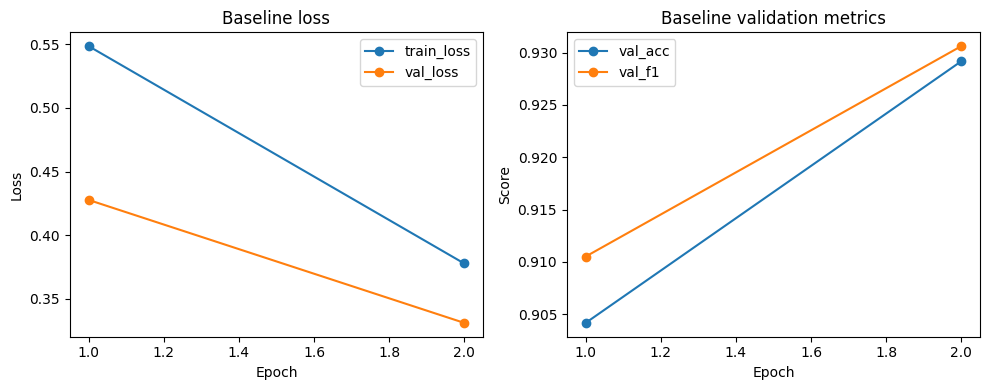

In [10]:
epochs = np.arange(1, len(baseline_history) + 1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, [row["train_loss"] for row in baseline_history], marker="o", label="train_loss")
plt.plot(epochs, [row["val_loss"] for row in baseline_history], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, [row["val_acc"] for row in baseline_history], marker="o", label="val_acc")
plt.plot(epochs, [row["val_f1"] for row in baseline_history], marker="o", label="val_f1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Baseline validation metrics")
plt.legend()
plt.tight_layout()
plt.show()

### What to inspect in CEMI

After running this notebook, start the local viewer if needed:

```bash
cemi gateway
cemi view
```

Then inspect these behaviors in the workspace:

- the FP32 run and the PTQ run both appear under the same project
- the PTQ run carries lineage back to the FP32 baseline
- compare shows `Case`, `Target Device`, and `Decision Policy` from the notebook writer calls
- compare should surface a decision-policy conflict because the FP32 run logs `Quality` while the PTQ run logs `Memory`
- artifacts should include config, metrics JSON, weights, and the notebook reference itself